# Titanic Survival Prediction: Logistic Regression vs SVM

**Goal:** build two classifiers on the Titanic dataset, compare them on the same train/test split, and use them to predict survival for new passengers.

Steps:
1. Load and explore the data
2. Select features and build a preprocessing pipeline
3. Train Logistic Regression and SVM
4. Evaluate on the test set (accuracy, precision, recall, F1)
5. Compare the two models
6. Predict survival for three new passengers

## 1. Load and explore the data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set()

df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print("Shape:", df.shape)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Survival counts (0 = No, 1 = Yes):")
print(df["Survived"].value_counts())

Shape: (891, 12)

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival counts (0 = No, 1 = Yes):
Survived
0    549
1    342
Name: count, dtype: int64


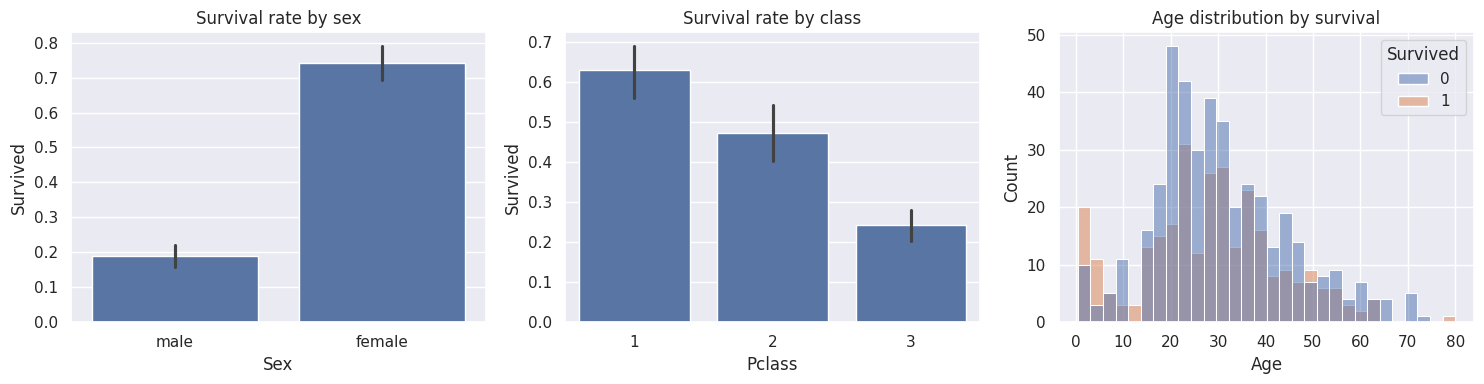

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(x="Sex", y="Survived", data=df, ax=axes[0])
axes[0].set_title("Survival rate by sex")
sns.barplot(x="Pclass", y="Survived", data=df, ax=axes[1])
axes[1].set_title("Survival rate by class")
sns.histplot(data=df, x="Age", hue="Survived", bins=30, ax=axes[2])
axes[2].set_title("Age distribution by survival")
plt.tight_layout()
plt.show()

Women and first-class passengers survived at much higher rates, so `Sex` and `Pclass` should be strong predictors.

## 2. Feature selection and preprocessing

- **Dropped:** `PassengerId`, `Name`, `Ticket` (identifiers) and `Cabin` (about 77% missing).
- **Numeric features** (`Age`, `SibSp`, `Parch`, `Fare`): fill missing values with the median, then standardise. Scaling matters for SVM and helps logistic regression converge.
- **Categorical features** (`Pclass`, `Sex`, `Embarked`): fill missing values with the most frequent value, then one-hot encode.

Everything is wrapped in a `Pipeline`, so the same preprocessing is applied automatically to the test set and to new passengers, and the imputer and scaler are fit only on training data.

In [4]:
numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

X = df[numeric_features + categorical_features]
y = df["Survived"]

# Stratify so train and test keep the same survival ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 712 | Test size: 179


In [5]:
def make_preprocessor():
    numeric_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ])

## 3. Train the models

In [6]:
log_reg = Pipeline([
    ("prep", make_preprocessor()),
    ("model", LogisticRegression(max_iter=1000)),
])

svm = Pipeline([
    ("prep", make_preprocessor()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale")),
])

log_reg.fit(X_train, y_train)
svm.fit(X_train, y_train)
print("Both models trained.")

Both models trained.


## 4. Evaluate on the test data

In [7]:
models = {"Logistic Regression": log_reg, "SVM (RBF)": svm}
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1})

    print("=" * 50)
    print(name)
    print("=" * 50)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 score : {f1:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["Not survived", "Survived"]))

Logistic Regression
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1 score : 0.7244

              precision    recall  f1-score   support

Not survived       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

SVM (RBF)
Accuracy : 0.8156
Precision: 0.8214
Recall   : 0.6667
F1 score : 0.7360

              precision    recall  f1-score   support

Not survived       0.81      0.91      0.86       110
    Survived       0.82      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



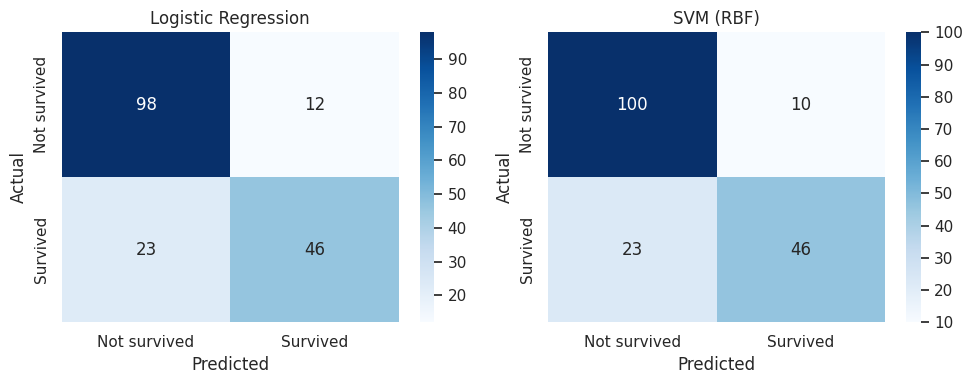

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not survived", "Survived"],
                yticklabels=["Not survived", "Survived"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

**Recall** here is the share of passengers who actually survived that the model correctly identified: TP / (TP + FN).

## 5. Compare the two algorithms

In [9]:
results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.8045,0.7931,0.6667,0.7244
SVM (RBF),0.8156,0.8214,0.6667,0.7360


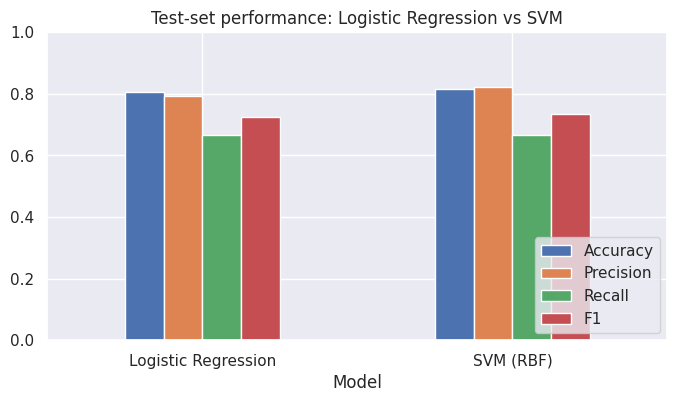

In [10]:
results_df.plot(kind="bar", figsize=(8, 4), ylim=(0, 1))
plt.title("Test-set performance: Logistic Regression vs SVM")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

A single test split of about 180 passengers is small, so a difference of one or two percentage points can be luck. 5-fold cross-validation on the full dataset gives a more reliable comparison.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    recalls = cross_val_score(model, X, y, cv=cv, scoring="recall")
    print(f"{name:20s} accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})   "
          f"recall: {recalls.mean():.4f} (+/- {recalls.std():.4f})")

Logistic Regression  accuracy: 0.7969 (+/- 0.0146)   recall: 0.7016 (+/- 0.0401)


SVM (RBF)            accuracy: 0.8215 (+/- 0.0195)   recall: 0.6929 (+/- 0.0528)


## 6. Predict survival for three new passengers

The DataFrame has the same columns as the training features. The pipelines handle scaling and encoding automatically.

In [12]:
new_passengers = pd.DataFrame({
    "Pclass":   [1, 3, 2],
    "Sex":      ["female", "male", "female"],
    "Age":      [28, 22, 35],
    "SibSp":    [0, 1, 1],
    "Parch":    [0, 0, 2],
    "Fare":     [100.0, 7.25, 26.0],
    "Embarked": ["C", "S", "S"],
})

label_map = {0: "Not survived", 1: "Survived"}

output = new_passengers.copy()
output["Logistic Regression"] = pd.Series(log_reg.predict(new_passengers)).map(label_map)
output["SVM"] = pd.Series(svm.predict(new_passengers)).map(label_map)
output["LogReg P(survive)"] = log_reg.predict_proba(new_passengers)[:, 1].round(3)

output

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Logistic Regression,SVM,LogReg P(survive)
0,1,female,28,0,0,100.00,C,Survived,Survived,0.955
1,3,male,22,1,0,7.25,S,Not survived,Not survived,0.088
2,2,female,35,1,2,26.00,S,Survived,Survived,0.701


In [13]:
for i in range(len(new_passengers)):
    p = new_passengers.iloc[i]
    print(f"Passenger {i+1}: {p['Sex']}, age {p['Age']}, class {p['Pclass']}, fare {p['Fare']}")
    print(f"   Logistic Regression -> {output.loc[i, 'Logistic Regression']}")
    print(f"   SVM                 -> {output.loc[i, 'SVM']}")

Passenger 1: female, age 28, class 1, fare 100.0
   Logistic Regression -> Survived
   SVM                 -> Survived
Passenger 2: male, age 22, class 3, fare 7.25
   Logistic Regression -> Not survived
   SVM                 -> Not survived
Passenger 3: female, age 35, class 2, fare 26.0
   Logistic Regression -> Survived
   SVM                 -> Survived


## Conclusion

- Both models reach similar results, and both rely mainly on sex and passenger class. Recall is the weaker metric for both: they miss roughly a third of actual survivors on the test split.
- The RBF SVM was slightly ahead on accuracy (about 2 points in cross-validation), while logistic regression had slightly higher cross-validated recall. These gaps are small relative to the fold-to-fold variation.
- Logistic regression is simpler, faster and gives interpretable coefficients and probabilities.
- The RBF SVM can fit non-linear patterns, which may explain its small accuracy edge, but it is harder to interpret. Tuning `C` and `gamma` (for example with `GridSearchCV`) could widen or close the gap.